In [8]:
!pip install -U scikit-learn jinja2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 30.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
from sklearn import decomposition
from sklearn import datasets
from sklearn.cluster import KMeans


We will apply PCA to [IRIS dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set) from [sklearn](https://scikit-learn.org/dev/auto_examples/decomposition/plot_pca_iris.html)

This dataset is made of 4 features:
*   sepal length
*   sepal width
*   petal length
*   petal width

We use PCA to project this 4 feature space into a 3-dimensional space.

In [10]:
iris = datasets.load_iris()

print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [11]:
# Assign the feature data (X) and target labels (y) from the iris dataset
X = iris.data
y = iris.target

# Print the type and shape of the feature data (X) and display the first row
print(type(X))
print(X.shape)
print(X[0])
print('------')
# Print the type and shape of the target labels (y) and display the first label
print(type(y))
print(y.shape)
print(y[0])
print('------')
# Print the names of the features and target classes
print(iris.feature_names)
print(iris.target_names)

<class 'numpy.ndarray'>
(150, 4)
[5.1 3.5 1.4 0.2]
------
<class 'numpy.ndarray'>
(150,)
0
------
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [12]:
# Print a header for the dataset information
# and iterate through each feature to calculate and print its statistics

def get_dataset_info(X, feature_names):
    print('Feature name\tmin value\tmean\tmax v\tVariance\tStandard deviation\n')
    for idx in range(len(feature_names)):

        # Calculate min, mean, max, variance, and standard deviation for the current feature
        # Note: np.sqrt(np.var(X[:,idx])) is used for standard deviation
        print(f'{feature_names[idx]}\t{X[:,idx].min()}\t{X[:,idx].mean():.2f}\t{X[:,idx].max()}\t{np.sqrt(np.var(X[:,idx])):.2f}\t{np.sqrt(np.var(X[:,idx])):.2f}')

get_dataset_info(X, iris.feature_names)

Feature name	min value	mean	max v	Variance	Standard deviation

sepal length (cm)	4.3	5.84	7.9	0.83	0.83
sepal width (cm)	2.0	3.06	4.4	0.43	0.43
petal length (cm)	1.0	3.76	6.9	1.76	1.76
petal width (cm)	0.1	1.20	2.5	0.76	0.76


In [13]:
import pandas as pd

# Calculate the correlation matrix among the features in the data set (X) w/o the target label
# Convert the numpy array X to a pandas DataFrame to use the .corr() method
# Apply a background gradient style to the correlation matrix for better visualization

pd.DataFrame(X).corr().style.background_gradient(cmap='Blues')

,0,1,2,3
0,1.000000,-0.117570,0.871754,0.817941
1,-0.117570,1.000000,-0.428440,-0.366126
2,0.871754,-0.428440,1.000000,0.962865
3,0.817941,-0.366126,0.962865,1.000000


In [14]:
# Calculate the correlation matrix among the features in the data set w/ the target label
pd.DataFrame((np.column_stack((X,y)))).corr().style.background_gradient(cmap='Blues')

,0,1,2,3,4
0,1.000000,-0.117570,0.871754,0.817941,0.782561
1,-0.117570,1.000000,-0.428440,-0.366126,-0.426658
2,0.871754,-0.428440,1.000000,0.962865,0.949035
3,0.817941,-0.366126,0.962865,1.000000,0.956547
4,0.782561,-0.426658,0.949035,0.956547,1.000000


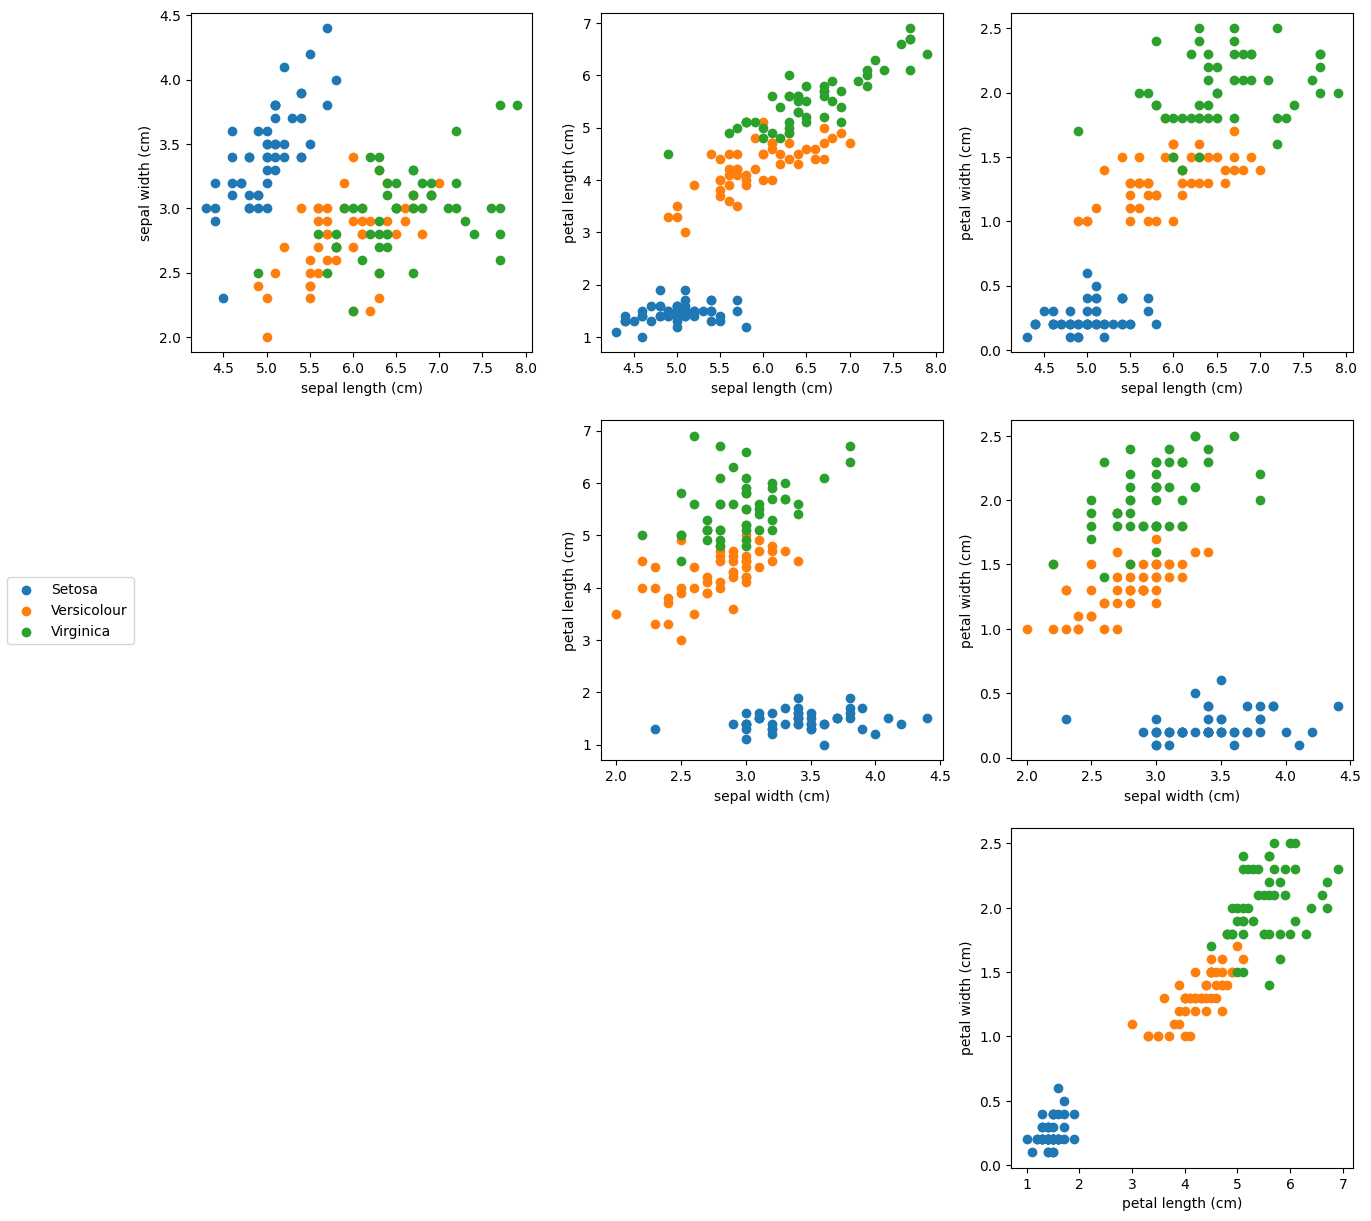

In [28]:
fig = plt.figure(figsize=(15, 15))

# Create a dictionary to map feature indices to their names
feature_dict = {}
for idx, item in enumerate(iris.feature_names):
    feature_dict[idx] = item

n_features = X.shape[1]

# Plot scatter plots for all unique pairs of features
# The outer loop iterates through each feature (i)
for i in range(n_features):
    # The inner loop iterates through the remaining features (j) to form unique pairs
    for j in range(i + 1, n_features):
        # Create a subplot for the current pair of features
        # The subplot layout is 3x3, and the position is calculated as 3*i + j
        sub_plt = plt.subplot(3, 3, 3 * i + j)
        # Set the x-axis label to the name of the i-th feature
        sub_plt.set_xlabel(f'{feature_dict[i]}')
        # Set the y-axis label to the name of the j-th feature
        sub_plt.set_ylabel(f'{feature_dict[j]}')

        # Plot data points for each class (Setosa, Versicolour, Virginica)
        # X[y==0, i] selects all samples of class 0 and their i-th feature value
        # X[y==0, j] selects all samples of class 0 and their j-th feature value
        sub_plt.scatter(X[y == 0, i], X[y == 0, j])
        sub_plt.scatter(X[y == 1, i], X[y == 1, j])
        sub_plt.scatter(X[y == 2, i], X[y == 2, j])

# Add a single legend for all subplots to the center left of the figure
fig.legend(('Setosa', 'Versicolour', 'Virginica'), loc='center left')
# Display the plot
plt.show()

In [32]:
# Print the first feature (sepal length) of the dataset
print(X[:,0])
print('-'*40)
# Print the mean of the first feature
print(X[:,0].mean())
print('-'*40)
# Print the first feature after subtracting its mean (mean-centering)
print(X[:,0] - X[:,0].mean())
print('-'*40)
print(X.shape)

[5.1 4.9 4.7 4.6 5.  5.4 4.6 5.  4.4 4.9 5.4 4.8 4.8 4.3 5.8 5.7 5.4 5.1
 5.7 5.1 5.4 5.1 4.6 5.1 4.8 5.  5.  5.2 5.2 4.7 4.8 5.4 5.2 5.5 4.9 5.
 5.5 4.9 4.4 5.1 5.  4.5 4.4 5.  5.1 4.8 5.1 4.6 5.3 5.  7.  6.4 6.9 5.5
 6.5 5.7 6.3 4.9 6.6 5.2 5.  5.9 6.  6.1 5.6 6.7 5.6 5.8 6.2 5.6 5.9 6.1
 6.3 6.1 6.4 6.6 6.8 6.7 6.  5.7 5.5 5.5 5.8 6.  5.4 6.  6.7 6.3 5.6 5.5
 5.5 6.1 5.8 5.  5.6 5.7 5.7 6.2 5.1 5.7 6.3 5.8 7.1 6.3 6.5 7.6 4.9 7.3
 6.7 7.2 6.5 6.4 6.8 5.7 5.8 6.4 6.5 7.7 7.7 6.  6.9 5.6 7.7 6.3 6.7 7.2
 6.2 6.1 6.4 7.2 7.4 7.9 6.4 6.3 6.1 7.7 6.3 6.4 6.  6.9 6.7 6.9 5.8 6.8
 6.7 6.7 6.3 6.5 6.2 5.9]
----------------------------------------
5.843333333333334
----------------------------------------
[-0.74333333 -0.94333333 -1.14333333 -1.24333333 -0.84333333 -0.44333333
 -1.24333333 -0.84333333 -1.44333333 -0.94333333 -0.44333333 -1.04333333
 -1.04333333 -1.54333333 -0.04333333 -0.14333333 -0.44333333 -0.74333333
 -0.14333333 -0.74333333 -0.44333333 -0.74333333 -1.24333333 -0.74333333

In [33]:
# Initialize an empty list to store the mean-centered features
X_new = []
# Iterate through each feature (column) of the dataset X
for i in range(X.shape[1]):
    # For each feature, subtract its mean from all values in that feature
    # This process is called mean-centering or de-meaning the data
    # The resulting mean-centered feature is then appended to the X_new list
    X_new.append(X[:,i] - X[:,i].mean())

# Convert it as np array
X_new_2 = np.stack(X_new, axis=1)

In [20]:
# Initialize PCA with 4 components
pca = decomposition.PCA(n_components=4)
# Fit PCA to the mean-centered data (X_new_2)
pca.fit(X_new_2)

# Calculate the total variation explained by the principal components
# This is done by summing the squares of the singular values
total_variation = np.sum(pca.singular_values_ ** 2)

# Print the singular values and the calculated total variation
print(f'singular values {pca.singular_values_}')
print(f'Variance: {total_variation:.2f}')

singular values [25.09996044  6.01314738  3.41368064  1.88452351]
Variance: 681.37


In [21]:
# Internally it executes the mean centering

pca = decomposition.PCA(n_components=4)
pca.fit(X)

total_variation = np.sum(pca.singular_values_ ** 2)

print(f'singular values {pca.singular_values_}')
print(f'Variance: {total_variation:.2f}')

singular values [25.09996044  6.01314738  3.41368064  1.88452351]
Variance: 681.37


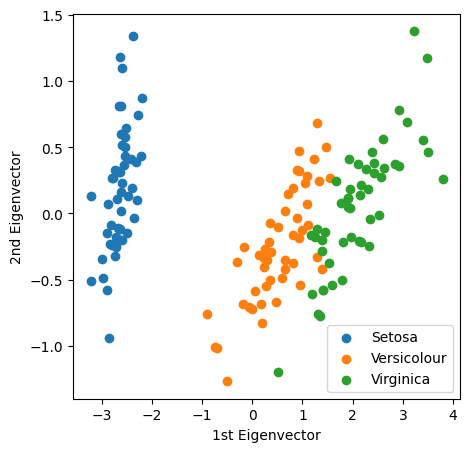

Variance w/ 2 components: 666.17 that is equal to 97.77% of the total variance


In [23]:
fig = plt.figure(figsize=(5, 5))
pca = decomposition.PCA(n_components=2)
pca.fit(X)
X_2 = pca.transform(X)

plt.xlabel('1st Eigenvector')
plt.ylabel('2nd Eigenvector')

plt.scatter(X_2[y == 0, 0], X_2[y == 0, 1], label='Setosa')
plt.scatter(X_2[y == 1, 0], X_2[y == 1, 1], label='Versicolour')
plt.scatter(X_2[y == 2, 0], X_2[y == 2, 1], label='Virginica')

plt.legend()

plt.show()

# calculate the partial variance
tv2 = np.sum(pca.singular_values_ ** 2)
print(f'Variance w/ 2 components: {tv2:.2f} that is equal to {100*tv2/total_variation:4.2f}% of the total variance')

In [24]:
pd.DataFrame(X_2).corr().style.background_gradient(cmap='Blues')

,0,1
0,1.000000,0.000000
1,0.000000,1.000000


In [25]:
pca = decomposition.PCA(n_components=3)
pca.fit(X)
X_3 = pca.transform(X)

# calculate the partial variance
tv3 = np.sum(pca.singular_values_ ** 2)
print(f'Variance w/ 3 components: {tv3:.2f} that is equal to {100*tv3/total_variation:4.2f}% of the total variance')

Variance w/ 3 components: 677.82 that is equal to 99.48% of the total variance


In [27]:
pd.DataFrame(X_3).corr().style.background_gradient(cmap='Blues')

,0,1,2
0,1.000000,0.000000,0.000000
1,0.000000,1.000000,-0.000000
2,0.000000,-0.000000,1.000000


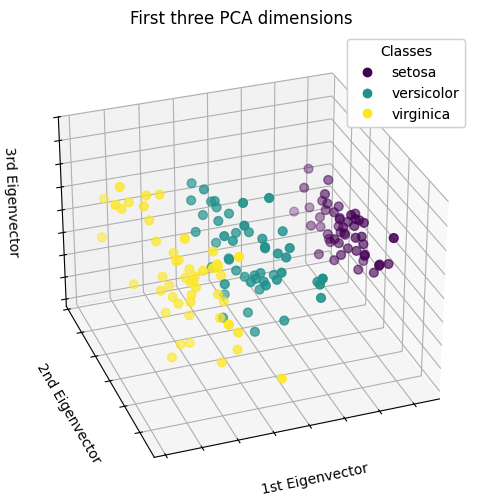

In [26]:
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

scatter = ax.scatter(
    X_3[:, 0],
    X_3[:, 1],
    X_3[:, 2],
    c=iris.target,
    s=40,
)

ax.set(
    title="First three PCA dimensions",
    xlabel="1st Eigenvector",
    ylabel="2nd Eigenvector",
    zlabel="3rd Eigenvector",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    iris.target_names.tolist(),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend1)

plt.show()

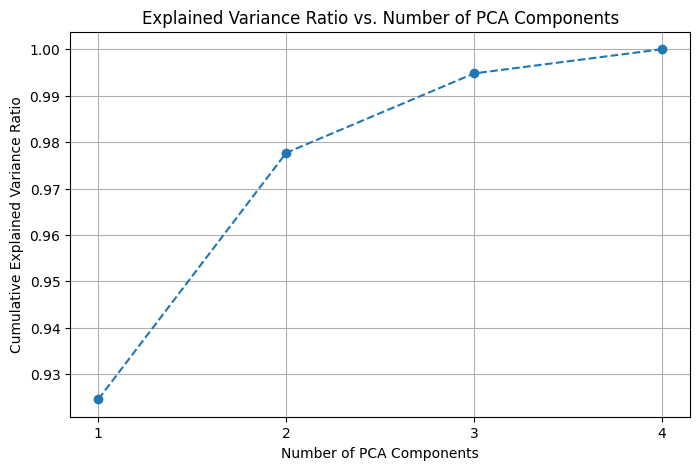

In [34]:
explained_variance_ratios = []
num_components = range(1, 5)

for n in num_components:
    pca_n = decomposition.PCA(n_components=n)
    pca_n.fit(X)
    explained_variance_ratios.append(np.sum(pca_n.explained_variance_ratio_))

plt.figure(figsize=(8, 5))
plt.plot(num_components, explained_variance_ratios, marker='o', linestyle='--')
plt.title('Explained Variance Ratio vs. Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.xticks(num_components)
plt.grid(True)
plt.show()

In [35]:
from sklearn.decomposition import TruncatedSVD

# Initialize TruncatedSVD with 3 components
svd = TruncatedSVD(n_components=3)
# Fit the SVD model to the data (X)
svd.fit(X)
# Print the explained variance ratio for each component
print(svd.explained_variance_ratio_)
# Print the sum of the explained variance ratios (total variance explained by 3 components)
print(svd.explained_variance_ratio_.sum())
# Print the singular values
print(svd.singular_values_)

[0.52875361 0.44845576 0.01757678]
0.9947861525045129
[95.95991387 17.76103366  3.46093093]


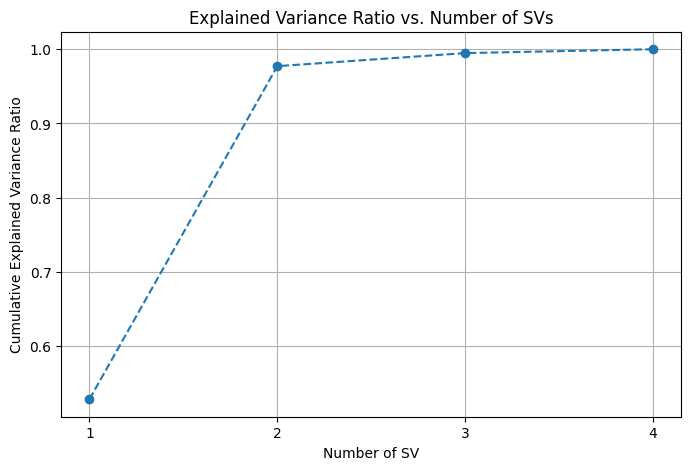

In [37]:
explained_variance_ratios = []
num_components = range(1, 5)

for n in num_components:
    svd_n = TruncatedSVD(n_components=n)
    svd_n.fit(X)
    explained_variance_ratios.append(np.sum(svd_n.explained_variance_ratio_))

plt.figure(figsize=(8, 5))
plt.plot(num_components, explained_variance_ratios, marker='o', linestyle='--')
plt.title('Explained Variance Ratio vs. Number of SVs')
plt.xlabel('Number of SV')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.xticks(num_components)
plt.grid(True)
plt.show()

[Arrythmia data set](https://archive.ics.uci.edu/dataset/5/arrhythmia) from the UCI Machine Learning Repository.

- What are the optimal components for PCA?
- What are the optimal components for SVD?